In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


data = {
    'suhu_celsius':   [27, 29, 31, 33, 35, 30, 28, 32, 34, 36, 29, 31, 33, 35, 30],
    'jml_penghuni':   [2,  3,  3,  4,  5,  2,  4,  3,  5,  4,  3,  2,  4,  5,  3],
    'luas_rumah_m2':  [36, 45, 54, 60, 72, 40, 50, 55, 70, 65, 42, 38, 58, 75, 48],
    'konsumsi_kwh':   [120,145,165,190,230,130,155,170,225,210,140,125,185,240,150]
}

df = pd.DataFrame(data)
print(df)

    suhu_celsius  jml_penghuni  luas_rumah_m2  konsumsi_kwh
0             27             2             36           120
1             29             3             45           145
2             31             3             54           165
3             33             4             60           190
4             35             5             72           230
5             30             2             40           130
6             28             4             50           155
7             32             3             55           170
8             34             5             70           225
9             36             4             65           210
10            29             3             42           140
11            31             2             38           125
12            33             4             58           185
13            35             5             75           240
14            30             3             48           150


Pada praktikum ini, saya membuat data sendiri yang menggambarkan hubungan antara tiga variabel independen yaitu suhu udara (°C), jumlah penghuni rumah, dan luas rumah (m²) terhadap konsumsi listrik (kWh/bulan) sebagai variabel dependen. Data terdiri dari 15 sampel. Tema ini dipilih karena relevan dan masuk akal secara logis semakin panas cuaca, semakin banyak penghuni, dan semakin luas rumah, maka konsumsi listrik cenderung semakin tinggi.

In [18]:
x = df[['suhu_celsius', 'jml_penghuni', 'luas_rumah_m2']]
y = df['konsumsi_kwh']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

Data dibagi menjadi 80% data training (12 data) dan 20% data testing (3 data) menggunakan train_test_split. Model yang digunakan adalah Regresi Linear Berganda dari library sklearn, dengan persamaan:

y = a + b₁x₁ + b₂x₂ + b₃x₃
di mana:

y = konsumsi listrik (kWh)

x₁ = suhu udara (°C)

x₂ = jumlah penghuni

x₃ = luas rumah (m²)

a = intercept,

b₁b₂b₃ = koefisien masing-masing variabel

In [19]:
print("Intercept (a) : ", model.intercept_)
print("Koefisien (b) : ", model.coef_)

Intercept (a) :  -62.04732551006302
Koefisien (b) :  [3.21354362 8.17243188 1.93131221]


In [20]:
y_pred = model.predict(x_test)

print("Prediksi : ", y_pred)
print("Nilai Asli : ", y_test.values)

Prediksi :  [211.86526626 127.30725467 110.59045574]
Nilai Asli :  [210 125 120]


Berdasarkan hasil training, model menghasilkan intercept dan tiga koefisien. Setiap koefisien menunjukkan seberapa besar pengaruh masing-masing variabel terhadap konsumsi listrik jika variabel lain dianggap tetap. Koefisien dengan nilai terbesar berarti variabel tersebut paling dominan mempengaruhi konsumsi listrik.

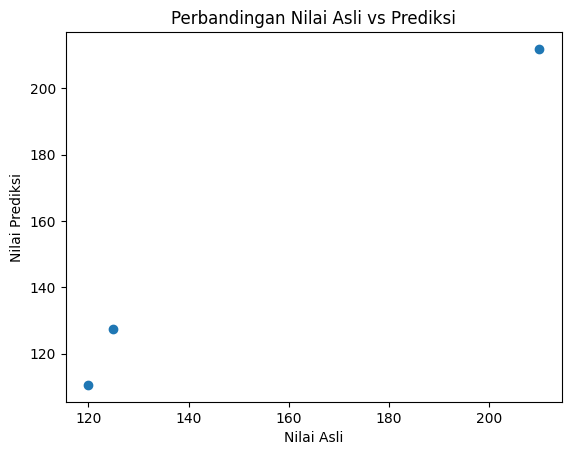

In [21]:
plt.scatter(y_test, y_pred)
plt.xlabel("Nilai Asli")
plt.ylabel("Nilai Prediksi")
plt.title("Perbandingan Nilai Asli vs Prediksi")
plt.show()

Scatter plot Nilai Asli vs Nilai Prediksi juga digunakan untuk menilai keakuratan model secara visual. Semakin dekat titik-titik ke garis diagonal (y = x), semakin baik model dalam memprediksi.

In [22]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 4.527355061708884
MSE: 32.447388488140554
RMSE: 5.6962609217047415


**Evaluasi Model**
Metrik dan Interpretasi :

*   MAE  : Rata-rata selisih antara konsumsi aktual dan prediksi (dalam kWh)
*   MSE  : Rata-rata kuadrat error — lebih sensitif terhadap prediksi yang meleset jauh
*   RMSE : Akar dari MSE

satuannya sama dengan data asli (kWh) — lebih mudah diinterpretasikan

In [23]:
data_baru = [[45, 7, 90]]
prediksi = model.predict(data_baru)

print("prediksi konsumsi Listrik : ", prediksi[0])

prediksi konsumsi Listrik :  313.5872598104211


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Model diuji dengan data baru: suhu 45°C, 7 penghuni, luas rumah 90 m². Model akan memprediksi berapa estimasi konsumsi listrik untuk kondisi tersebut. Hasil prediksi ini wajar jika lebih tinggi dari data training karena semua nilai inputnya berada di atas rata-rata data yang ada.